In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [6]:
uploaded=files.upload()

Saving CarPrices.csv to CarPrices.csv


In [9]:
df=pd.read_csv("CarPrices.csv",on_bad_lines='skip')

/tmp/ipykernel_3474/1776881329.py:1: DtypeWarning: Columns (8,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("CarPrices.csv",on_bad_lines='skip')


In [10]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,Unnamed: 16
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),NaN
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST),NaN
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST),NaN
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST),NaN
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST),NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493484 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547043 non-null  object 
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558837 non-null  object 
 14  sellingprice  558837 non-null  int64  
 15  saledate      558837 non-null  object 
 16  Unnamed: 16   26 non-null      object 
dtypes: float64(1), int64(2), object(14)
memory usage

In [12]:
df.describe(include='all')

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,Unnamed: 16
count,558837.000000,548536,548438,548186,545642,493484,558833,558837,547043.0,558743.000000,558088,558088,558837,558837.0,558837.000000,558837,26
unique,NaN,96,973,1972,87,4,550297,64,94.0,NaN,46,17,14266,2179.0,NaN,3766,21
top,NaN,Ford,Altima,Base,Sedan,automatic,automatic,fl,1.9,NaN,black,black,nissan-infiniti lt,12500.0,NaN,Tue Feb 10 2015 01:30:00 GMT-0800 (PST),Tue Jun 02 2015 02:15:00 GMT-0700 (PDT)
freq,NaN,93554,19349,55817,199437,475914,22,82945,30077.0,NaN,110970,244329,19693,1274.0,NaN,5334,4
mean,2010.038927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68320.016670,NaN,NaN,NaN,NaN,13611.264979,NaN,NaN
std,3.966864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53398.544224,NaN,NaN,NaN,NaN,9749.430357,NaN,NaN
min,1982.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,2007.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28371.000000,NaN,NaN,NaN,NaN,6900.000000,NaN,NaN
50%,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52254.000000,NaN,NaN,NaN,NaN,12100.000000,NaN,NaN
75%,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99109.000000,NaN,NaN,NaN,NaN,18200.000000,NaN,NaN


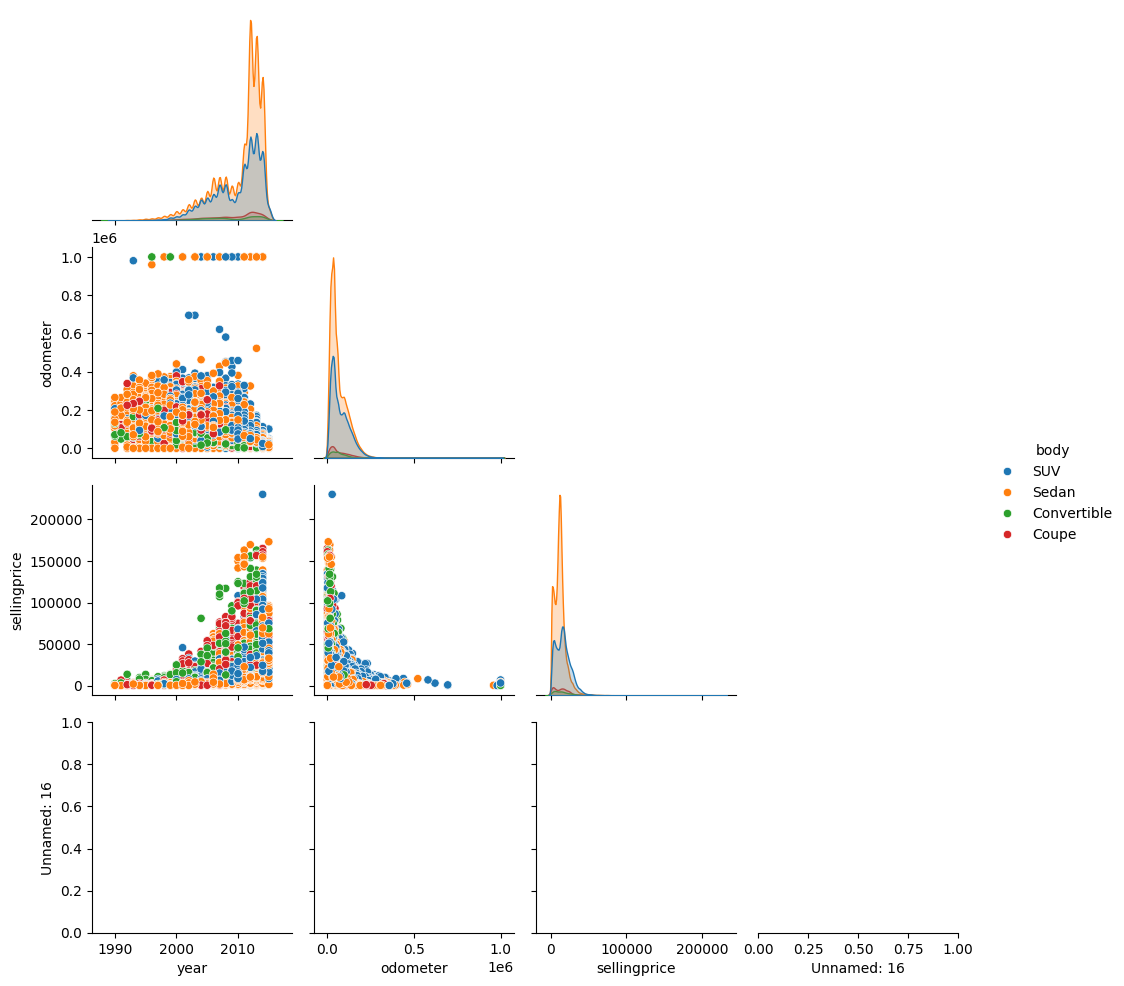

In [14]:
cars=["SUV","Sedan","Convertible","Coupe"]
sns.pairplot(df.query("body in @cars"),corner=True,hue='body')

### Insight

- Different vehicle body types exhibit distinct pricing and feature distributions.
- SUVs and Sedans appear more frequently in the dataset, indicating higher market demand.
- Certain body types generally command higher selling prices than others.

<Axes: >

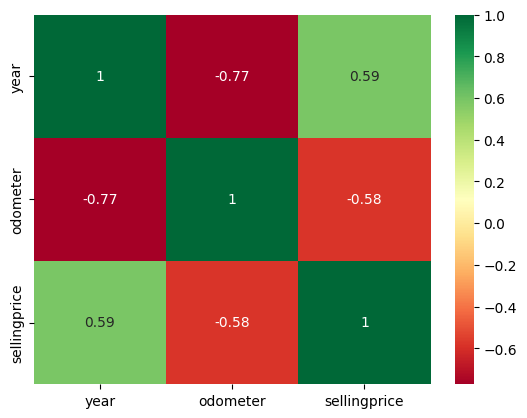

In [16]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),cmap='RdYlGn',annot=True)

### Insight

- Strong correlations exist between several numerical variables.
- Selling price shows a negative relationship with odometer readings, suggesting that cars with higher mileage generally sell for lower prices.
- The heatmap helps identify features that may be useful for predictive modeling.

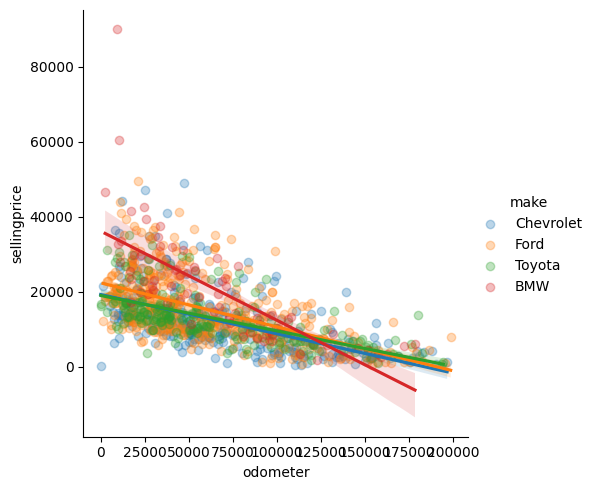

In [17]:
brand=['Ford','BMW','Toyota','Chevrolet']
sns.lmplot(x='odometer',y='sellingprice',data=df.query("make in @brand and sellingprice<150000 and odometer <200000").sample(1000),hue='make',scatter_kws={'alpha':.3})

### Insight

- Selling prices generally decrease as odometer readings increase.
- BMW vehicles maintain relatively higher resale values compared to the other selected brands.
- The relationship between mileage and price is consistent across most manufacturers.

/tmp/ipykernel_3474/4033480170.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='condition_bins',y='sellingprice',palette='viridis')


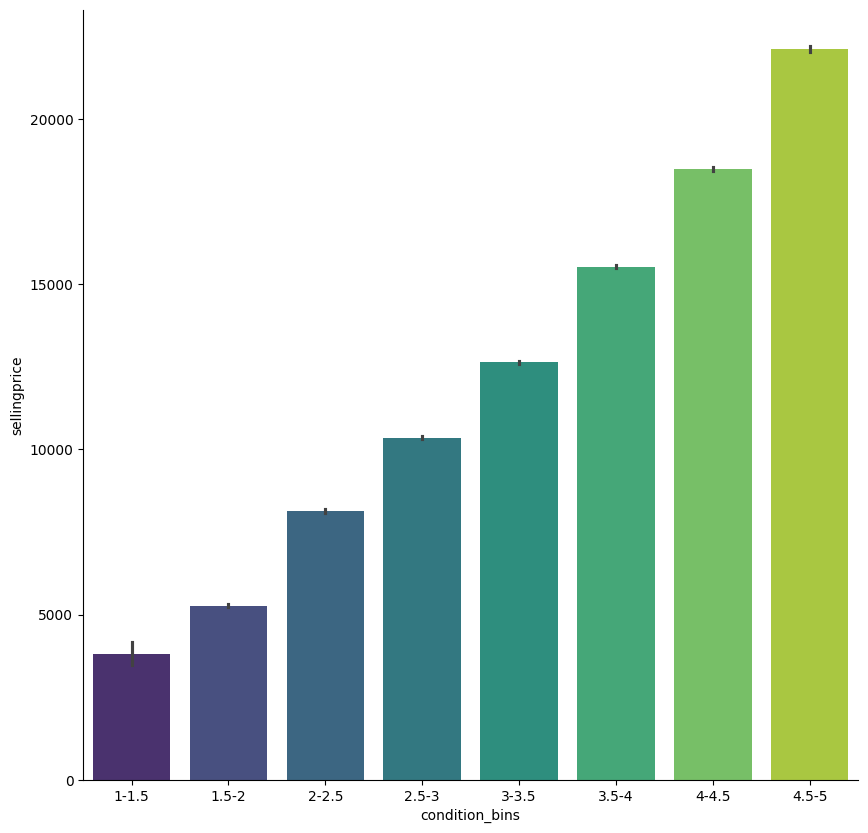

In [18]:
fig,ax=plt.subplots(figsize=(10,10))
bins=np.linspace(1,5,9)
labels=["1-1.5","1.5-2",'2-2.5','2.5-3','3-3.5','3.5-4','4-4.5','4.5-5']

# Convert the 'condition' column to numeric, coercing errors to NaN
df['condition'] = pd.to_numeric(df['condition'], errors='coerce')

# Optional: Drop rows where 'condition' became NaN after conversion
df.dropna(subset=['condition'], inplace=True)

df['condition_bins']=pd.cut(df['condition'],bins=bins,labels=labels)
sns.barplot(data=df,x='condition_bins',y='sellingprice',palette='viridis')
sns.despine()

### Insight

- Most vehicles fall within the average to good condition range.
- Very poor and excellent condition vehicles are comparatively less common.
- Vehicle condition plays an important role in determining resale value.

In [19]:
top10=df['make'].value_counts().iloc[:10].index

In [20]:
avg=(df.loc[df['make'].isin(top10)].pivot_table(index='make',columns="condition_bins",values={'sellingprice':'mean'}).droplevel(0,axis=1))
avg.head()

/tmp/ipykernel_3474/2773487725.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  avg=(df.loc[df['make'].isin(top10)].pivot_table(index='make',columns="condition_bins",values={'sellingprice':'mean'}).droplevel(0,axis=1))


condition_bins,1-1.5,1.5-2,2-2.5,2.5-3,3-3.5,3.5-4,4-4.5,4.5-5
make,,,,,,,,
BMW,4326.923077,6848.680865,10478.320029,12795.277669,16397.610281,21911.286118,28791.890310,35902.992693
Chevrolet,3021.031746,5384.030601,7425.967945,10325.668781,11622.675195,14436.514288,16733.687841,21580.124553
Chrysler,2354.545455,4301.224656,5367.031437,9077.602013,9247.621069,14813.315207,15212.500990,18388.446281
Dodge,4094.907407,5299.306603,7127.988641,9840.543230,10517.710952,14051.693213,14893.500000,18400.000000
Ford,4175.866667,5282.734146,8550.886379,10954.656807,13394.647490,15374.553012,17820.920366,20810.886556


### Insight

- A few manufacturers dominate the used car market.
- Brands such as Ford, Chevrolet, Toyota, and BMW appear frequently in the dataset.
- Popular brands contribute a significant share of the total listings.

<Axes: xlabel='condition_bins', ylabel='make'>

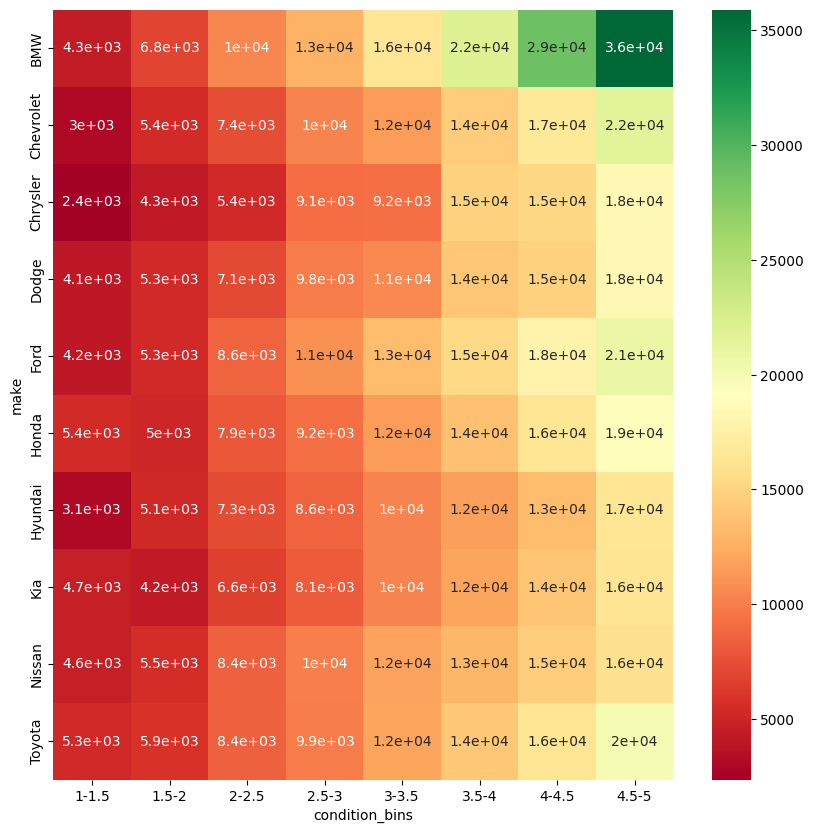

In [21]:
fig,ax=plt.subplots(figsize=(10,10))
sns.heatmap(avg,cmap='RdYlGn',annot=True)

### Insight

- Average selling prices generally increase with better vehicle condition.
- Premium manufacturers maintain higher resale values even at similar condition levels.
- Vehicle condition has a noticeable impact on average market price.

In [22]:
f150=df[df['model']=="F-150"]
f150.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,Unnamed: 16,condition_bins
983,2012,Ford,F-150,XLT,SuperCrew,NaN,1ftew1cm9ckd05952,ca,4.6,51189.0,gray,gray,"ford motor credit company,llc pd",19700,20200,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),NaN,4.5-5
1013,2012,Ford,F-150,FX2,SuperCrew,automatic,1ftfw1ct0cfb64807,ca,4.6,28687.0,gray,black,"ford motor credit company,llc pd",26700,30500,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),NaN,4.5-5
1052,2012,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1et3ckd61619,ca,3.9,27465.0,black,gray,"ford motor credit company,llc pd",26300,28800,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),NaN,3.5-4
1054,2012,Ford,F-150,XLT,SuperCrew,automatic,1ftfw1ef9cfc79834,ca,3.5,93858.0,white,gray,aaero sweet company,18900,19500,Wed Dec 17 2014 12:15:00 GMT-0800 (PST),NaN,3-3.5
1074,2012,Ford,F-150,Lariat,SuperCab,automatic,1ftfx1ef6cfc80260,ca,4.1,46444.0,red,black,"ford motor credit company,llc pd",26300,25600,Thu Dec 18 2014 12:00:00 GMT-0800 (PST),NaN,4-4.5


<Axes: xlabel='sellingprice', ylabel='Count'>

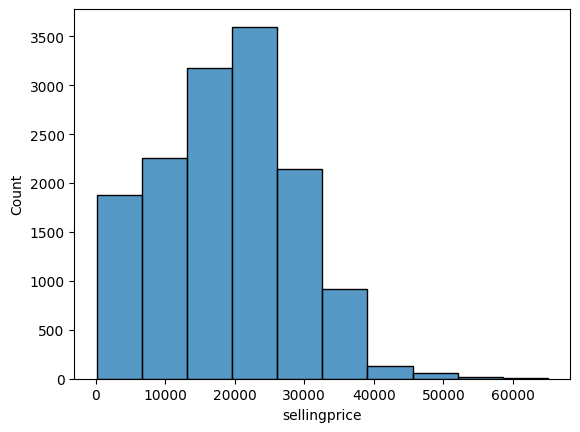

In [23]:
sns.histplot(data=f150,x='sellingprice',bins=10)

### Insight

- Most Ford F-150 vehicles are concentrated within a specific price range.
- The distribution highlights the most common resale prices while identifying a few higher-priced vehicles.

/tmp/ipykernel_3474/2142825562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=f150,x='trim',y='sellingprice',palette='husl');
/tmp/ipykernel_3474/2142825562.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90);


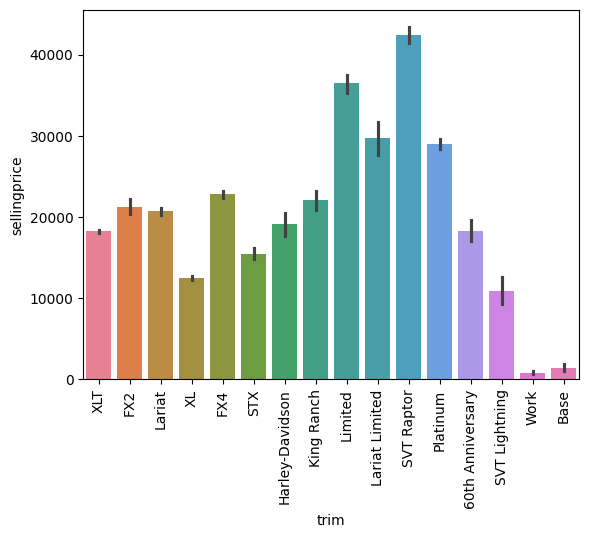

In [24]:
fig,ax=plt.subplots()
sns.barplot(data=f150,x='trim',y='sellingprice',palette='husl');
ax.set_xticklabels(ax.get_xticklabels(),rotation=90);

### Insight

- Premium trims such as Platinum and SVT Raptor command higher resale prices.
- Base trims like XL generally have lower average selling prices.
- Trim level significantly influences vehicle valuation.

In [25]:
trim_list=['XL','XLT','Platinum','SVT Raptor']

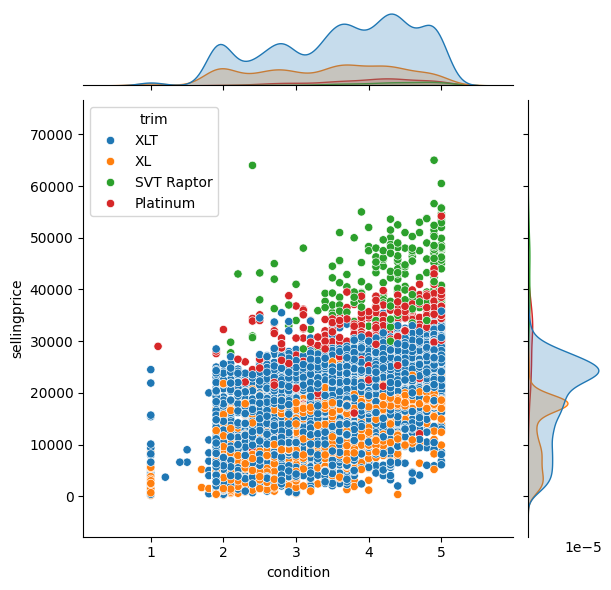

In [26]:
sns.jointplot(data=f150.query("trim in @trim_list"),x='condition',y='sellingprice',kind='scatter',hue='trim')

### Insight

- Better vehicle condition is associated with higher selling prices.
- Premium trims consistently outperform standard trims across different condition levels.
- Both condition and trim contribute to resale value.